In [ ]:
import sys
import yfinance as yf
import matplotlib.pyplot as plt
import fitz
import os
import matplotlib.dates as mdates
import pandas as pd
!{sys.executable} -m pip install pymupdf

[*********************100%***********************]  1 of 1 completed


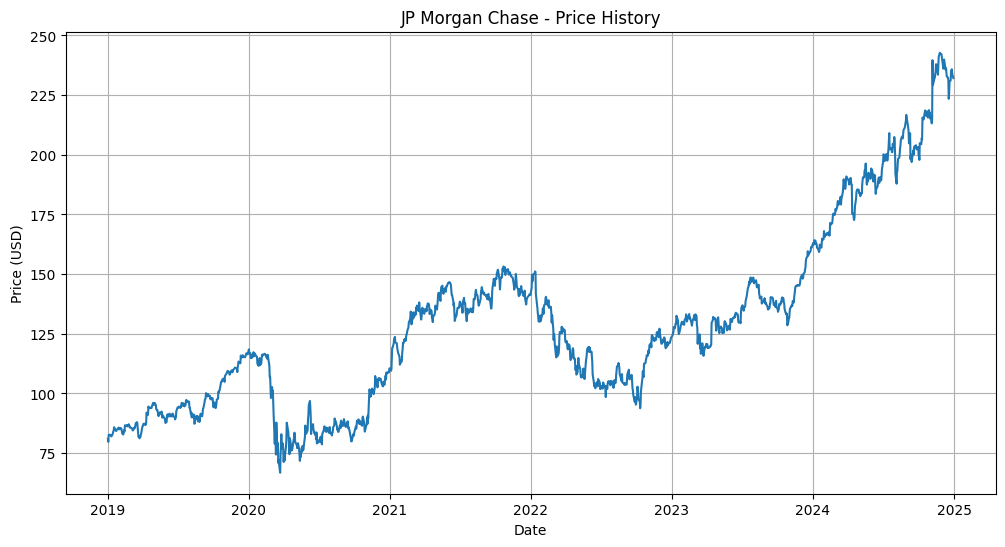

In [ ]:
#JPM price history 2019-2024
jpm = yf.download("JPM", start="2019-01-01", end="2024-12-31")

plt.figure(figsize=(12,6))
plt.plot(jpm["Close"])
plt.title("JP Morgan Chase - Price History")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

In [20]:
jpm.head()

Price,Close,High,Low,Open,Volume
Ticker,JPM,JPM,JPM,JPM,JPM
2019-01-02,80.836510,81.219082,78.093396,78.101531,15670900
2019-01-03,79.687660,81.148312,79.343013,80.943165,16286400
2019-01-04,82.625404,82.822345,80.647775,81.328868,16935200
2019-01-07,82.682854,83.265473,81.821230,82.412057,15430700
2019-01-08,82.526917,83.552656,81.689916,83.396742,13578800


In [ ]:
#extracting text from trasncript
def extract_text_from_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    text = ""
    for page in doc:
        text+= page.get_text()
    return text

text = extract_text_from_pdf("../Data/1q20-earnings-transcript.pdf")
print(text[:2000])


 
 
1Q20 FINANCI AL RESULTS  
EARNINGS CALL TRANSCRIPT 
April 14, 2020 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
2 
 
MANAGEMENT DISCUSSION SECTION 
 ......................................................................................................................................................................................................................................................  
 
Operator: Good morning, ladies and gentlemen. Welcome to JPMorgan Chase's First Quarter 2020 Earnings Call. This call is being recorded. 
Your line will be muted for the duration of the call. We will now go live to the presentation. Please stand by. 
 
At this time, I would like to turn the call over to JPMorgan Chase's Chairman and CEO, Jamie Dimon; and Chief Financial Officer, Jennifer 
Piepszak. Ms. Piepszak, please go ahead. 
 .............................................................................................................................................................

In [ ]:
transcripts = {}

transcript_files = {
    "Q1 2020": "../Data/1q20-earnings-transcript.pdf",
    "Q2 2020": "../Data/2q20-earnings-transcript.pdf",
    "Q3 2020": "../Data/3q20-earnings-transcript.pdf",
    "Q4 2020": "../Data/JPM-4Q20-Earnings-Call-Final-Transcript.pdf",
    "Q1 2021": "../Data/1q21-earnings-transcript.pdf",
    "Q2 2021": "../Data/JPM-2Q21-Earnings-Call-Final-Transcript.pdf",
    "Q3 2021": "../Data/JPM-3Q21-Earnings-Call-Final-Transcript-PDF.pdf",
    "Q4 2021": "../Data/JPM-4Q21-Earnings-Call-Final-Transcript.pdf",
    "Q1 2022": "../Data/1Q22-earnings-transcript.pdf",
    "Q2 2022": "../Data/jpmc-2q22-earnings-call-final-transcript.pdf",
    "Q3 2022": "../Data/jpm-3Q22-earnings-call-final-transcript.pdf",
    "Q4 2022": "../Data/jpm-4q22-earnings-call-final-transcript.pdf",
    "Q1 2023": "../Data/1q23-earnings-transcript.pdf",
    "Q2 2023": "../Data/2q23-earnings-transcript.pdf",
    "Q3 2023": "../Data/jpm-3q23-earnings-call-transcript.pdf",
    "Q4 2023": "../Data/jpm-4q23-earnings-call-transcript.pdf"
}

for quarter, path in transcript_files.items():
    transcripts[quarter] = extract_text_from_pdf(path)

In [23]:
#installing VADER
!{sys.executable} -m pip install nltk

In [ ]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

sentiment_scores = {}

for quarter, text in transcripts.items():
    scores = sia.polarity_scores(text)
    sentiment_scores[quarter] = scores
    print(f"{quarter}: {scores}")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/tejasvidawra/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Q1 2020: {'neg': 0.054, 'neu': 0.827, 'pos': 0.119, 'compound': 1.0}
Q2 2020: {'neg': 0.058, 'neu': 0.829, 'pos': 0.113, 'compound': 1.0}
Q3 2020: {'neg': 0.039, 'neu': 0.84, 'pos': 0.121, 'compound': 1.0}
Q4 2020: {'neg': 0.033, 'neu': 0.84, 'pos': 0.127, 'compound': 1.0}
Q1 2021: {'neg': 0.036, 'neu': 0.833, 'pos': 0.131, 'compound': 1.0}
Q2 2021: {'neg': 0.03, 'neu': 0.829, 'pos': 0.141, 'compound': 1.0}
Q3 2021: {'neg': 0.023, 'neu': 0.829, 'pos': 0.148, 'compound': 1.0}
Q4 2021: {'neg': 0.028, 'neu': 0.825, 'pos': 0.147, 'compound': 1.0}
Q1 2022: {'neg': 0.051, 'neu': 0.812, 'pos': 0.137, 'compound': 1.0}
Q2 2022: {'neg': 0.046, 'neu': 0.822, 'pos': 0.133, 'compound': 1.0}
Q3 2022: {'neg': 0.047, 'neu': 0.831, 'pos': 0.123, 'compound': 1.0}
Q4 2022: {'neg': 0.042, 'neu': 0.824, 'pos': 0.134, 'compound': 1.0}
Q1 2023: {'neg': 0.049, 'neu': 0.828, 'pos': 0.123, 'compound': 1.0}
Q2 2023: {'neg': 0.031, 'neu': 0.848, 'pos': 0.122, 'compound': 1.0}
Q3 2023: {'neg': 0.036, 'neu': 0.83, 

In [56]:
#Averaging sentiment scores per line for each transcipt

nltk.download('punkt')
nltk.download('punkt_tab')

def get_average_sentiment(text):
    sentences = nltk.sent_tokenize(text)
    scores = [sia.polarity_scores(s)['compound'] for s in sentences]
    return {
        'mean': sum(scores) / len(scores),
        'min': min(scores),
        'max': max(scores),
        'sentence_count': len(sentences)
    }

averaged_scores = {}

for quarter, text in transcripts.items():
    averaged_scores[quarter] = get_average_sentiment(text)
    print(f"{quarter}: {averaged_scores[quarter]}")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/tejasvidawra/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/tejasvidawra/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Q1 2020: {'mean': 0.13806305084745737, 'min': -0.9402, 'max': 0.9126, 'sentence_count': 590}
Q2 2020: {'mean': 0.11338398328690782, 'min': -0.8322, 'max': 0.9313, 'sentence_count': 718}
Q3 2020: {'mean': 0.14500727848101236, 'min': -0.8918, 'max': 0.9109, 'sentence_count': 632}
Q4 2020: {'mean': 0.1797630165289255, 'min': -0.9022, 'max': 0.9201, 'sentence_count': 968}
Q1 2021: {'mean': 0.1760416796267494, 'min': -0.9413, 'max': 0.9929, 'sentence_count': 643}
Q2 2021: {'mean': 0.19031099873577742, 'min': -0.85, 'max': 0.9527, 'sentence_count': 791}
Q3 2021: {'mean': 0.22593689922480636, 'min': -0.6997, 'max': 0.93, 'sentence_count': 645}
Q4 2021: {'mean': 0.2160166666666665, 'min': -0.9231, 'max': 0.9559, 'sentence_count': 894}
Q1 2022: {'mean': 0.14082106135986713, 'min': -0.8555, 'max': 0.9011, 'sentence_count': 603}
Q2 2022: {'mean': 0.1513303482587063, 'min': -0.919, 'max': 0.9612, 'sentence_count': 603}
Q3 2022: {'mean': 0.13716738738738712, 'min': -0.802, 'max': 0.9169, 'sentence_

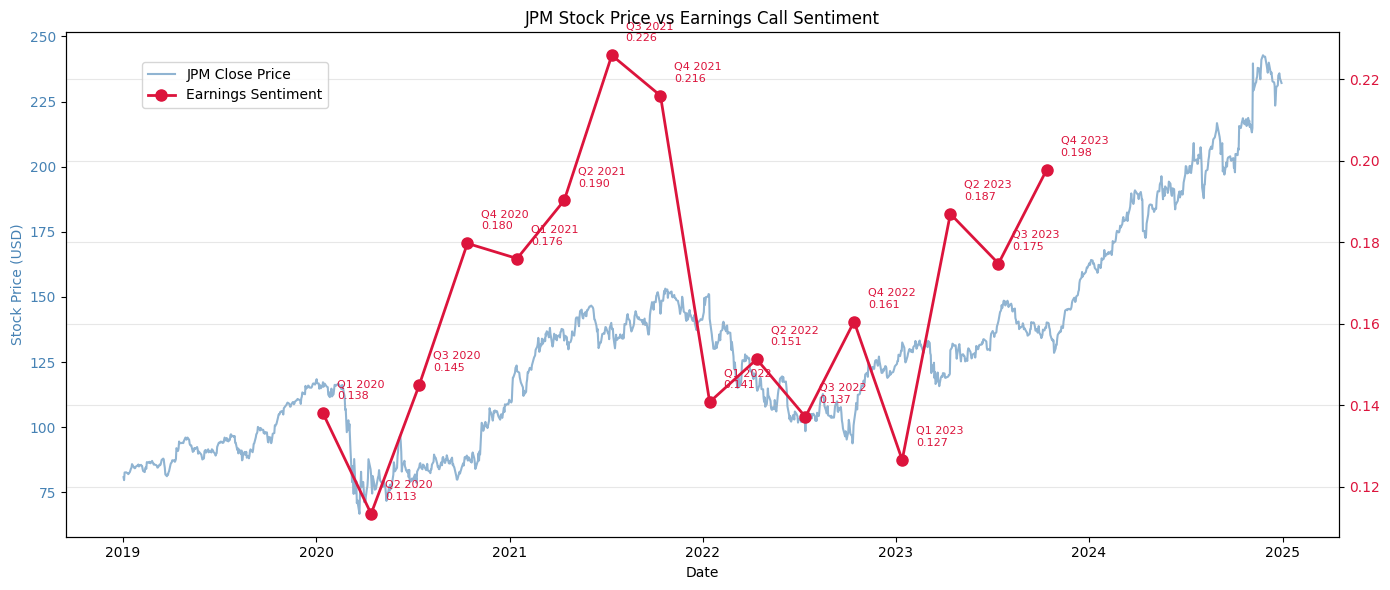

In [57]:
#plotting price history against sentiment scores
dates = [
    '2020-01-14',  # Q4 2019 / full year
    '2020-04-14',  # Q1 2020
    '2020-07-14',  # Q2 2020
    '2020-10-13',  # Q3 2020
    '2021-01-15',  # Q4 2020
    '2021-04-14',  # Q1 2021
    '2021-07-13',  # Q2 2021
    '2021-10-13',  # Q3 2021
    '2022-01-14',  # Q4 2021
    '2022-04-13',  # Q1 2022
    '2022-07-14',  # Q2 2022
    '2022-10-14',  # Q3 2022
    '2023-01-13',  # Q4 2022
    '2023-04-14',  # Q1 2023
    '2023-07-14',  # Q2 2023
    '2023-10-13',  # Q3 2023
]
means = [averaged_scores[q]['mean'] for q in averaged_scores.keys()]
quarters = list(transcripts.keys())

dates_dt = pd.to_datetime(dates)
jpm_prices = [jpm['Close'].asof(d) for d in dates_dt]

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(jpm.index, jpm['Close'], color='steelblue', alpha=0.6, label='JPM Close Price')
ax1.set_ylabel('Stock Price (USD)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(dates_dt, means, color="crimson", marker='o', linewidth=2, markersize=8, label='Earnings Sentiment')
ax2.tick_params(axis='y', labelcolor='crimson')

#Adding Quarter Labels
for i, (d,q,m) in enumerate(zip(dates_dt, quarters, means)):
    ax2.annotate(f'{q}\n{m:.3f}',
                 xy=(d,m),
                 xytext=(10,10),
                 textcoords='offset points',
                 fontsize=8,
                 color="crimson")
    
plt.title('JPM Stock Price vs Earnings Call Sentiment')
ax1.set_xlabel('Date')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [58]:
dimon_only = {}
for quarter, text in transcripts.items():
    total_text = text.split("......................................................................................................................................................................................................................................................")
    jamie_dimon = ""
    for piece in total_text:
        if("Jamie Dimon \nChairman & Chief Executive Officer" in piece):
            jamie_dimon += piece
    dimon_only[quarter] = jamie_dimon

dimon_scores ={}

for quarter, text in dimon_only.items():
    sentences = nltk.sent_tokenize(text)
    scores = [sia.polarity_scores(s)['compound'] for s in sentences]
    dimon_scores[quarter] = {
        "mean": sum(scores)/len(scores),
        "sentence_count": len(sentences)
    }
    print(f"{quarter}:  mean={dimon_scores[quarter]['mean']:.4f}, sentences={dimon_scores[quarter]['sentence_count']}")



Q1 2020:  mean=0.0435, sentences=98
Q2 2020:  mean=0.0858, sentences=308
Q3 2020:  mean=0.0611, sentences=110
Q4 2020:  mean=0.1421, sentences=361
Q1 2021:  mean=0.1195, sentences=109
Q2 2021:  mean=0.1565, sentences=173
Q3 2021:  mean=0.1301, sentences=105
Q4 2021:  mean=0.2038, sentences=238
Q1 2022:  mean=0.0764, sentences=159
Q2 2022:  mean=0.0707, sentences=168
Q3 2022:  mean=0.1446, sentences=406
Q4 2022:  mean=0.1559, sentences=488
Q1 2023:  mean=0.1177, sentences=425
Q2 2023:  mean=0.1783, sentences=418
Q3 2023:  mean=0.1727, sentences=382
Q4 2023:  mean=0.2143, sentences=306


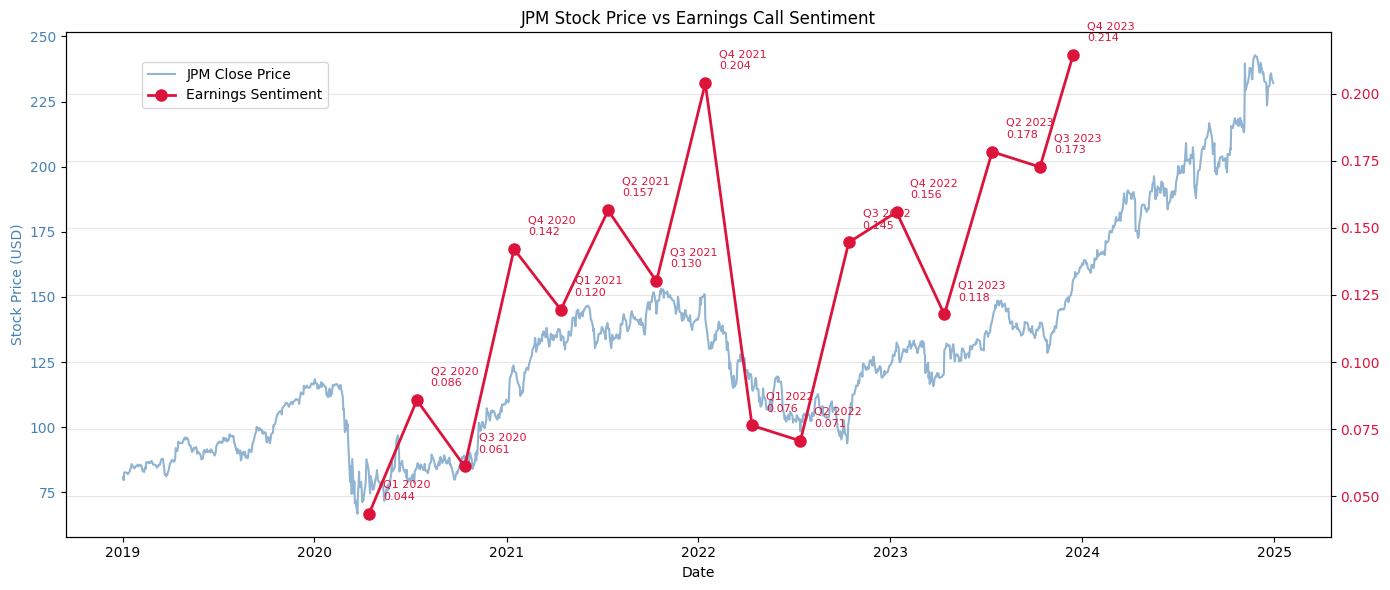

In [60]:
#plotting price history against sentiment scores
dates = [
    '2020-04-14',  # Q1 2020
    '2020-07-14',  # Q2 2020
    '2020-10-13',  # Q3 2020
    '2021-01-15',  # Q4 2020
    '2021-04-14',  # Q1 2021
    '2021-07-13',  # Q2 2021
    '2021-10-13',  # Q3 2021
    '2022-01-14',  # Q4 2021
    '2022-04-13',  # Q1 2022
    '2022-07-14',  # Q2 2022
    '2022-10-14',  # Q3 2022
    '2023-01-13',  # Q4 2022
    '2023-04-14',  # Q1 2023
    '2023-07-14',  # Q2 2023
    '2023-10-13',  # Q3 2023
    '2023-12-15',  # Q4 2023
]
means = [dimon_scores[q]['mean'] for q in dimon_scores.keys()]
quarters = list(transcripts.keys())

dates_dt = pd.to_datetime(dates)
jpm_prices = [jpm['Close'].asof(d) for d in dates_dt]

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(jpm.index, jpm['Close'], color='steelblue', alpha=0.6, label='JPM Close Price')
ax1.set_ylabel('Stock Price (USD)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(dates_dt, means, color="crimson", marker='o', linewidth=2, markersize=8, label='Earnings Sentiment')
ax2.tick_params(axis='y', labelcolor='crimson')

#Adding Quarter Labels
for i, (d,q,m) in enumerate(zip(dates_dt, quarters, means)):
    ax2.annotate(f'{q}\n{m:.3f}',
                 xy=(d,m),
                 xytext=(10,10),
                 textcoords='offset points',
                 fontsize=8,
                 color="crimson")
    
plt.title('JPM Stock Price vs Earnings Call Sentiment')
ax1.set_xlabel('Date')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
